In [1]:
# import libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in data
url = "../data/processed/stops_clean.csv.gz"
stops = pd.read_csv(url)
stops.head()

/var/folders/b7/4yf7b9tn1t1ck0mv8h93dssc0000gn/T/ipykernel_33587/1342288186.py:3: DtypeWarning: Columns (0,6) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(url)


,raw_row_number,date,time,location,lat,lng,district,zone,subject_age,subject_race,...,Male,Female,y_arrest,stop_date,stop_time,stop_datetime,stop_hour,stop_dow,stop_month,stop_year
0,149223,2012-01-01,13:01:00,Barracks St & N Peters St,29.960840,-90.057711,8,E,35.0,black,...,743.0,543.0,0,2012-01-01,0 days 13:01:00,2012-01-01 13:01:00,13,6,1,2012
1,149149,2012-01-01,13:08:00,Dumaine St & N Rampart St,29.962113,-90.066910,8,E,26.0,white,...,1286.0,784.0,0,2012-01-01,0 days 13:08:00,2012-01-01 13:08:00,13,6,1,2012
2,149086,2012-01-01,01:11:00,S Carrollton Ave & Olive St,29.963036,-90.112752,2,T,27.0,black,...,1035.0,1315.0,0,2012-01-01,0 days 01:11:00,2012-01-01 01:11:00,1,6,1,2012
3,149225,2012-01-01,13:12:00,Barracks St & N Peters St,29.960840,-90.057711,8,E,19.0,white,...,743.0,543.0,0,2012-01-01,0 days 13:12:00,2012-01-01 13:12:00,13,6,1,2012
4,149081,2012-01-01,01:13:00,S Rendon & Washington,29.961357,-90.099890,2,V,67.0,white,...,617.0,1154.0,0,2012-01-01,0 days 01:13:00,2012-01-01 01:13:00,1,6,1,2012


In [3]:
# examine columns
stops.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'zone', 'subject_age', 'subject_race', 'subject_sex',
       'officer_assignment', 'type', 'arrest_made', 'citation_issued',
       'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs',
       'contraband_weapons', 'frisk_performed', 'search_conducted',
       'search_person', 'search_vehicle', 'search_basis', 'reason_for_stop',
       'vehicle_color', 'vehicle_make', 'vehicle_model', 'vehicle_year',
       'raw_actions_taken', 'raw_subject_race', 'final_lat', 'final_lng',
       'geometry', 'index_right', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID',
       'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'Geographic Area Name',
       'Total!!Estimate!!Population 25 years and over',
       'Total!!Estimate!!Population 25 years and over!!Less than 9th grade',
       'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma',
  

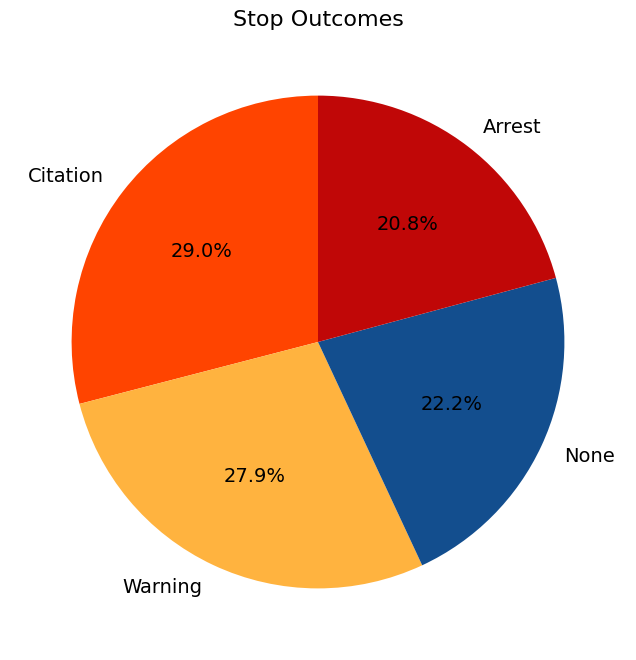

In [4]:
# fill NaN outcomes with "None"
stops['outcome_filled'] = stops['outcome'].fillna('None')

# map colors to a consistent pallette that aligns with outcome severity
color_mapping = {
    'Arrest': '#C00707',
    'Citation': '#FF4400',
    'Warning': '#FFB33F',
    'None': '#134E8E'
}
legend_order = ["Arrest", "Citation", "Warning", "None"]

# count number of outcomes
outcome_counts = stops['outcome_filled'].value_counts()

# match colors to outcomes
colors = [color_mapping.get(o, "gray") for o in outcome_counts.index]

# create pie chart for stop ouctomes
plt.figure(figsize=(8,8))
plt.pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14},
    colors=colors
)
plt.title("Stop Outcomes", fontsize=16)
plt.show()

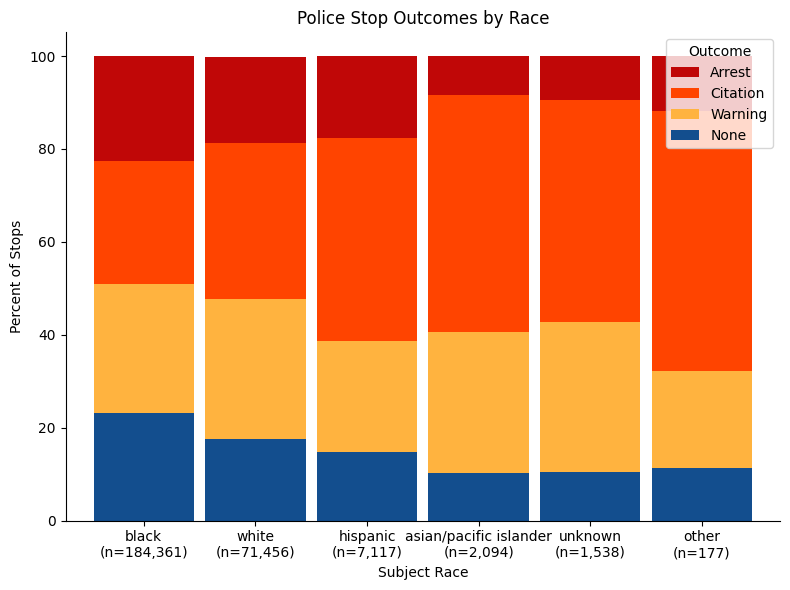

In [5]:
# count numbers of traffic stops by race
race_counts = stops['subject_race'].value_counts()

# find race percentages
race_outcome = pd.crosstab(
   stops['subject_race'],
   stops['outcome_filled'],
   normalize='index'
) * 100
race_outcome = race_outcome.round(1)

# order rows by frequency
race_outcome = race_outcome.loc[race_counts.index]

# label bars with counts
race_labels = [
    f"{race}\n(n={race_counts[race]:,})"
    for race in race_outcome.index
]

# reorder columns to stack
plot_cols = legend_order[::-1]
race_outcome = race_outcome[plot_cols]

# plot stacked bars
ax = race_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=[color_mapping[c] for c in plot_cols],
    width=0.9
)
# clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticklabels(race_labels, rotation=0)
plt.xlabel("Subject Race")
plt.ylabel("Percent of Stops")
plt.title("Police Stop Outcomes by Race")

# reorder legend
handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[plot_cols.index(c)] for c in legend_order]
plt.legend(ordered_handles, legend_order, title="Outcome", loc = "upper right")

plt.tight_layout()
plt.show()


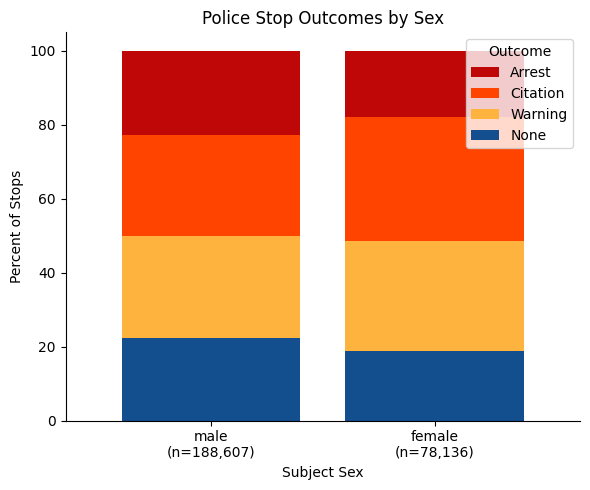

In [6]:
# count numbers of traffic stops by sex
sex_counts = stops['subject_sex'].value_counts()

# find row percentages
sex_outcome = pd.crosstab(
    stops['subject_sex'],
    stops['outcome_filled'],
    normalize='index'
) * 100
sex_outcome = sex_outcome.round(1)

# reorder rows by frequency
sex_outcome = sex_outcome.loc[sex_counts.index]

# label bars with counts
sex_labels = [
    f"{sex}\n(n={sex_counts[sex]:,})"
    for sex in sex_outcome.index
]
# reorder columns
plot_cols = legend_order[::-1]
sex_outcome = sex_outcome[plot_cols]

# plot stacked bars
ax = sex_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5),
    color=[color_mapping[c] for c in plot_cols],
    width=0.8
)

# clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticklabels(sex_labels, rotation=0)
plt.xlabel("Subject Sex")
plt.ylabel("Percent of Stops")
plt.title("Police Stop Outcomes by Sex")

# reorder legend
handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[plot_cols.index(c)] for c in legend_order]
plt.legend(ordered_handles, legend_order, title="Outcome")

plt.tight_layout()
plt.show()


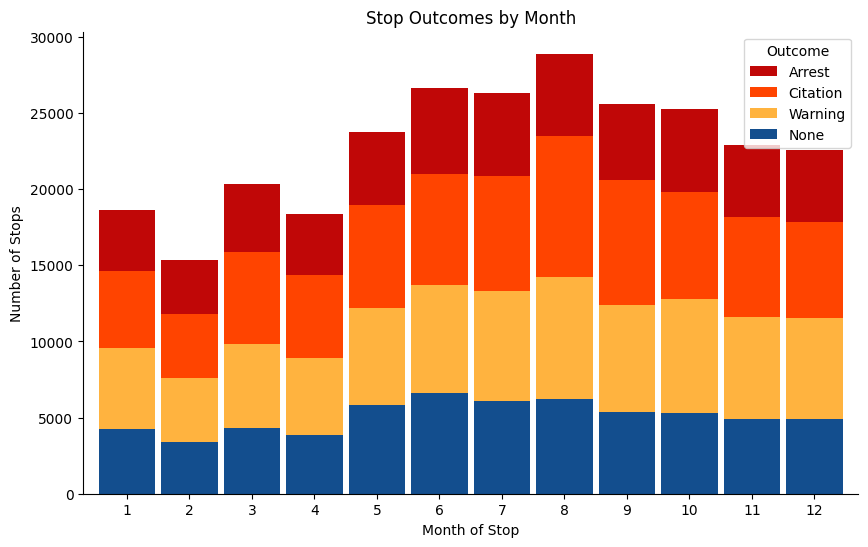

In [7]:
# find monthly counts
month_outcome_counts = pd.crosstab(
    stops['stop_month'],
    stops['outcome_filled']
)
plot_cols = legend_order[::-1]
month_outcome_counts = month_outcome_counts[plot_cols]

# plot stacked bars
ax = month_outcome_counts.plot(
    kind='bar',
    stacked=True,
    color=[color_mapping[c] for c in plot_cols],
    figsize=(10,6),
    width=0.9
)

# clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Month of Stop")
plt.ylabel("Number of Stops")
plt.title("Stop Outcomes by Month")
plt.xticks(rotation=0)

# reorder legend
handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[plot_cols.index(c)] for c in legend_order]
plt.legend(ordered_handles, legend_order, title="Outcome", loc='upper right')

plt.show()

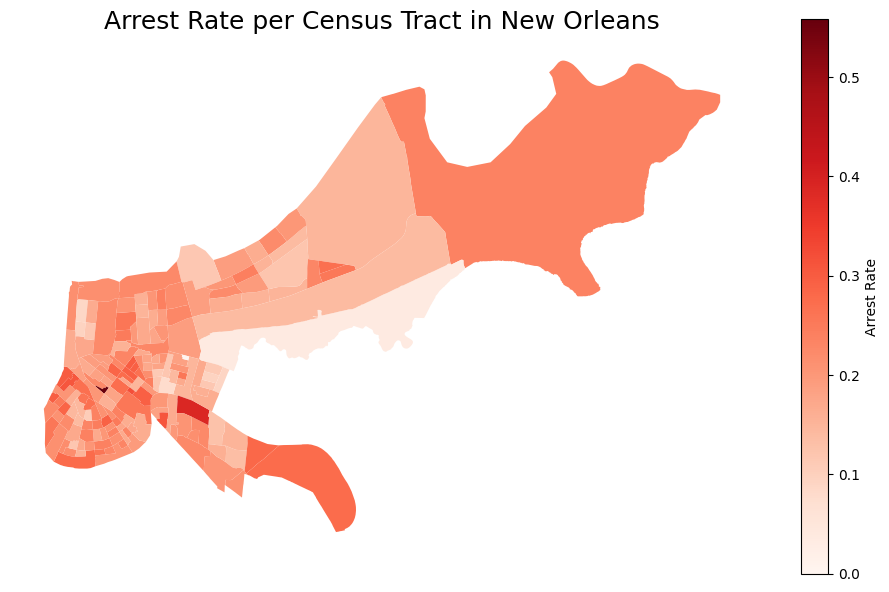

In [8]:
# load shapefile for tracts
no_tracts = gpd.read_file("../data/raw/shapefiles/tl_2015_22_tract.shp")

# keep only Orleans Parish tracts
no_tracts = no_tracts[no_tracts['COUNTYFP'] == '071'].copy()

# aggregate arrest data and counts by GEOID
tract_data = stops.groupby('GEOID').agg(
    stop_count=('y_arrest', 'count'),
    arrest_count=('y_arrest', 'sum')
).reset_index()

# find arrest rate
tract_data['arrest_rate'] = tract_data['arrest_count'] / tract_data['stop_count']

# make sure GEOID is string
tract_data['GEOID'] = tract_data['GEOID'].astype(str)
no_tracts['GEOID'] = no_tracts['GEOID'].astype(str)

# only keep tracts within the police stop data
stop_geoids = stops['GEOID'].unique().astype(str)
tracts_nola = no_tracts[no_tracts['GEOID'].isin(stop_geoids)]

# merge spatial and arrest data
tracts_arrest = tracts_nola.merge(tract_data, on='GEOID', how='left')

# fill missing values
tracts_arrest['arrest_rate'] = tracts_arrest['arrest_rate'].fillna(0)

# plot map
fig, ax = plt.subplots(1,1, figsize=(12,12))
tracts_arrest.plot(
    column='arrest_rate',
    cmap='Reds',
    legend=True,
    linewidth=0.3,
    ax=ax,
    legend_kwds={'shrink':0.6, 'label':"Arrest Rate"}
)
ax.set_title("Arrest Rate per Census Tract in New Orleans", fontsize=18)
ax.axis('off')
plt.show()

/var/folders/b7/4yf7b9tn1t1ck0mv8h93dssc0000gn/T/ipykernel_33587/2632387474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


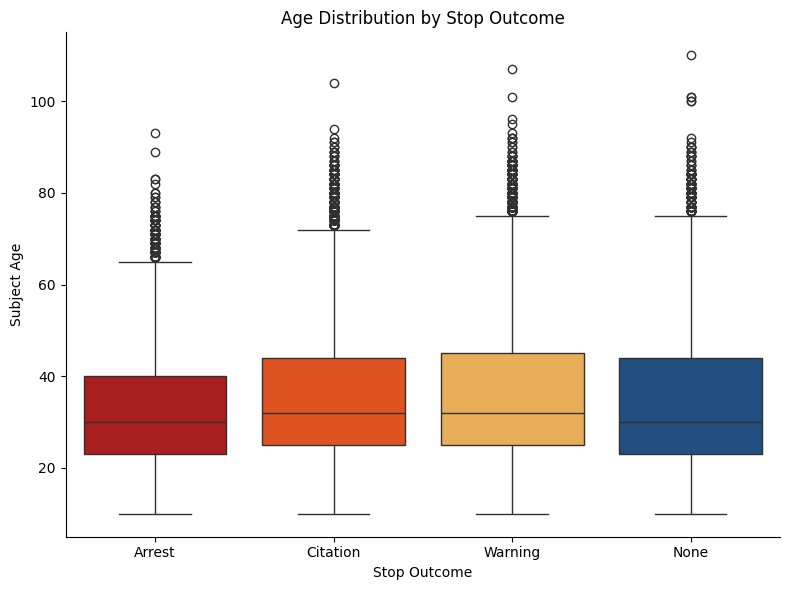

In [9]:
# create boxplot
plt.figure(figsize=(8,6))
sns.boxplot(
    x="outcome_filled",
    y="subject_age",
    data=stops,
    order=legend_order,
    palette=color_mapping
)

# clean axes
plt.xlabel("Stop Outcome")
plt.ylabel("Subject Age")
plt.title("Age Distribution by Stop Outcome")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/b7/4yf7b9tn1t1ck0mv8h93dssc0000gn/T/ipykernel_33587/537404803.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_arrest = stops.groupby('age_bin').agg(


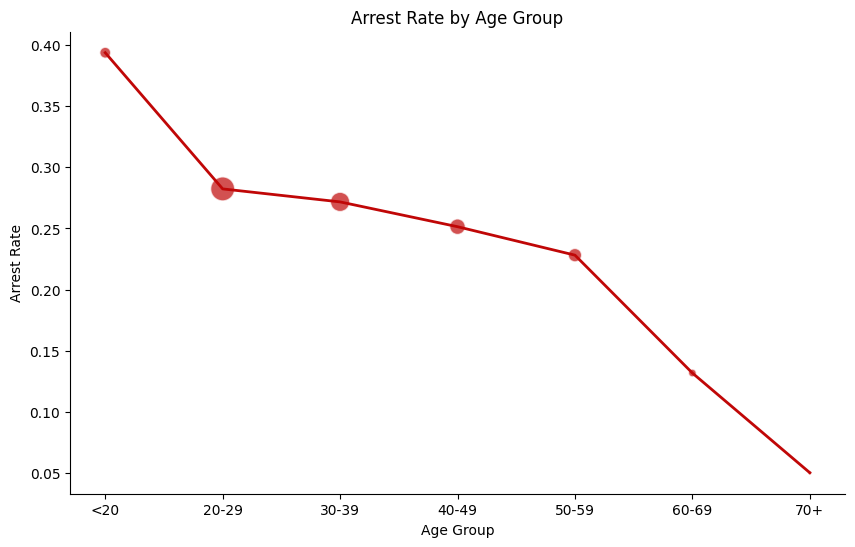

In [10]:
# create age bins
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
stops['age_bin'] = pd.cut(stops['subject_age'], bins=bins, labels=labels, right=False)

# find arrest rate by age group
age_arrest = stops.groupby('age_bin').agg(
    total_stops=('outcome', 'count'),
    arrests=('y_arrest', 'sum')
).reset_index()
age_arrest['arrest_rate'] = age_arrest['arrests'] / age_arrest['total_stops']

# line plot
plt.figure(figsize=(10,6))
plt.plot(age_arrest["age_bin"], age_arrest["arrest_rate"], color="#C00707",linewidth=2
)

plt.scatter(age_arrest["age_bin"], age_arrest["arrest_rate"], s=age_arrest["total_stops"] / age_arrest["total_stops"].max() * 300, color="#C00707", alpha=0.7,edgecolor="white"
)


# clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Age Group")
plt.ylabel("Arrest Rate")
plt.title("Arrest Rate by Age Group")
plt.show()

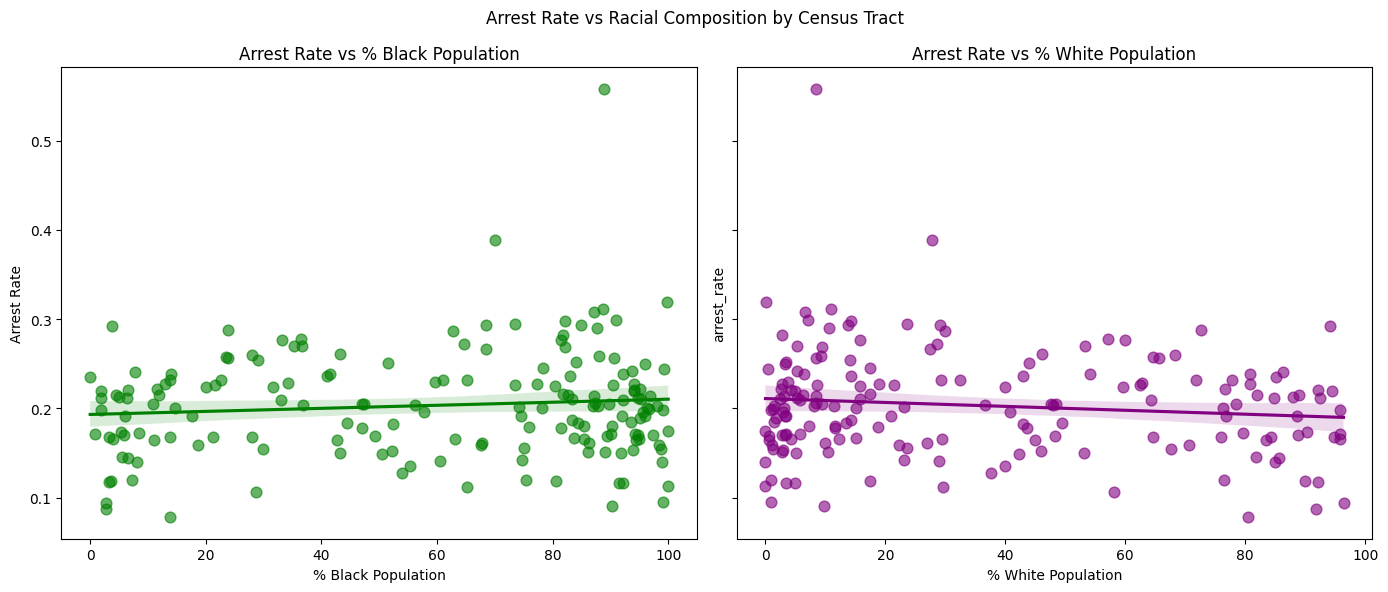

In [11]:
# find race counts by tract
race_counts = stops.groupby("GEOID")[[
    "\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0Black or African American",
    "\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0White",
    "\xa0\xa0\xa0\xa0Total population"
]].first().reset_index()

# find race percentages
race_counts["perc_black"] = (
    race_counts["\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0Black or African American"] /
    race_counts["\xa0\xa0\xa0\xa0Total population"]
) * 100
race_counts["perc_white"] = (
    race_counts["\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0White"] /
    race_counts["\xa0\xa0\xa0\xa0Total population"]
) * 100

# find number of arrests and stops
tract_data = stops.groupby("GEOID").agg(
    num_arrests=("y_arrest", "sum"),
    total_stops=("y_arrest", "size"),
    mean_income=("Households!!Estimate!!Mean income (dollars)", "first")
).reset_index()

# merge data
tract_data = tract_data.merge(
    race_counts[["GEOID", "perc_black", "perc_white"]],
    on="GEOID",
    how="left"
)

# find arrest rate
tract_data["arrest_rate"] = (
    tract_data["num_arrests"] /
    tract_data["total_stops"]
)

# create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), sharey=True)
sns.regplot(
    x="perc_black",
    y="arrest_rate",
    data=tract_data,
    color="green",
    scatter_kws={"alpha":0.6, "s":60},
    ax=ax1
)
ax1.set_title("Arrest Rate vs % Black Population")
ax1.set_xlabel("% Black Population")
ax1.set_ylabel("Arrest Rate")
sns.regplot(
    x="perc_white",
    y="arrest_rate",
    data=tract_data,
    color="purple",
    scatter_kws={"alpha":0.6, "s":60},
    ax=ax2
)
ax2.set_title("Arrest Rate vs % White Population")
ax2.set_xlabel("% White Population")

plt.suptitle("Arrest Rate vs Racial Composition by Census Tract")

plt.tight_layout()
plt.show()

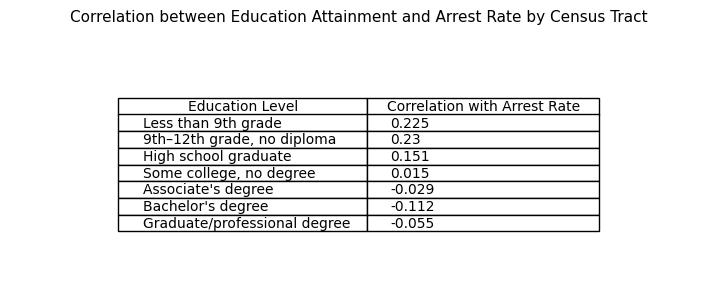

In [ ]:
# extract columns
edu_columns = [
       "Total!!Estimate!!Population 25 years and over!!Less than 9th grade",
       "Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma",
       "Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)",
       "Total!!Estimate!!Population 25 years and over!!Some college, no degree",
       "Total!!Estimate!!Population 25 years and over!!Associate's degree",
       "Total!!Estimate!!Population 25 years and over!!Bachelor's degree",
       "Total!!Estimate!!Population 25 years and over!!Graduate or professional degree",
]

# get education data by tract
edu_data = stops.groupby("GEOID")[edu_columns].first().reset_index()

# find arrest rate by tract
arrest_data = stops.groupby("GEOID").agg(
    num_arrests=("y_arrest", "sum"),
    total_stops=("y_arrest", "size")
).reset_index()
arrest_data["arrest_rate"] = (
    arrest_data["num_arrests"] /
    arrest_data["total_stops"]
)

# merge education and arrest data
arrest_rates_edu = arrest_data.merge(edu_data, on="GEOID", how="left")

# find correlations
corrs = arrest_rates_edu[edu_columns + ['arrest_rate']]\
    .corr()['arrest_rate']\
    .drop('arrest_rate')

# make into table
corr_df = corrs.reset_index()
corr_df.columns = ['Education Level', 'Correlation with Arrest Rate']

# made labels readable
corr_df['Education Level'] = corr_df['Education Level'].map({
    "Total!!Estimate!!Population 25 years and over!!Less than 9th grade": 'Less than 9th grade',
      "Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma": '9th–12th grade, no diploma',
     "Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)": 'High school graduate',
     "Total!!Estimate!!Population 25 years and over!!Some college, no degree": 'Some college, no degree',
   "Total!!Estimate!!Population 25 years and over!!Associate's degree": "Associate's degree",
     "Total!!Estimate!!Population 25 years and over!!Bachelor's degree": "Bachelor's degree",
     "Total!!Estimate!!Population 25 years and over!!Graduate or professional degree": 'Graduate/professional degree'
})

corr_df['Correlation with Arrest Rate'] = corr_df['Correlation with Arrest Rate'].round(3)

# plot table
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
table = ax.table(
    cellText=corr_df.values,
    colLabels=corr_df.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(corr_df.columns))))
plt.title(
    'Correlation between Education Attainment and Arrest Rate by Census Tract',
    pad=20,
    fontsize=11
)

plt.show()

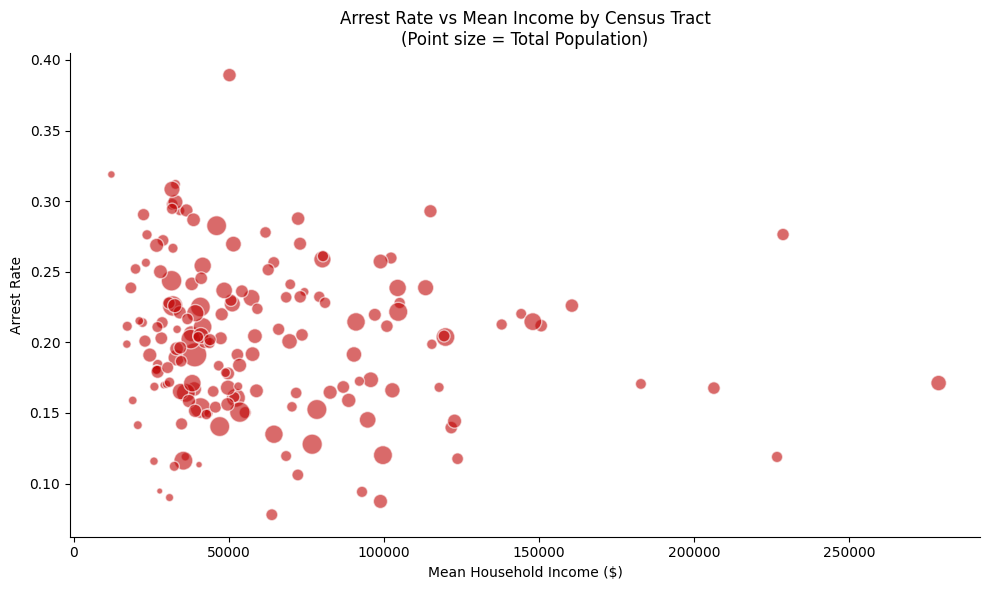

In [13]:
# add total population per tract to tract_data
pop_data = stops.groupby("GEOID")["\xa0\xa0\xa0\xa0Total population"].first().reset_index()
pop_data = pop_data.rename(columns={'\xa0\xa0\xa0\xa0Total population': 'total_population'})

# merge
tract_data = tract_data.merge(pop_data, on="GEOID", how="left")

# create scatterplot
plt.figure(figsize=(10,6))
plt.scatter(
    tract_data['mean_income'],
    tract_data['arrest_rate'],
    s=tract_data['total_population'] / tract_data['total_population'].max() * 300,  # scale points
    alpha=0.6,
    color="#C00707",
    edgecolor="white"
)

# clean axes
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# labels
plt.xlabel("Mean Household Income ($)")
plt.ylabel("Arrest Rate")
plt.title("Arrest Rate vs Mean Income by Census Tract\n(Point size = Total Population)")

plt.tight_layout()
plt.show()